In [1]:
# directional distribution - south side

In [2]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import Point
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import re
from shapely.wkt import loads
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import altair as alt
from scipy import ndimage
from PIL import Image

# Read & Convert Necessary Files

## CSVs

In [ ]:
metrics = pd.read_csv("data/wave_metrics.csv")
longest_gap = pd.read_csv("data/map_data.csv")

longest_gap.head()

,Unnamed: 0,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap
0,0,AJ-37,1874,0.0,0.000000,NaN,POLYGON ((-87.61869043688546 41.64974613192322...,NaN,NaN
1,1,AK-37,1874,0.0,4.198223,0.0,POLYGON ((-87.60967855897036 41.64454312178316...,NaN,NaN
2,2,AL-37,1874,0.0,0.001777,0.0,POLYGON ((-87.60066668105532 41.64974613192322...,1996.0,21.0
3,3,AM-37,1874,0.0,0.000000,NaN,POLYGON ((-87.59165480314022 41.64454312178316...,NaN,NaN
4,4,AN-37,1874,0.0,0.000000,NaN,POLYGON ((-87.58264292522512 41.64974613192322...,NaN,NaN


## My Favorite Shapes

In [4]:
south_chicago = gpd.read_file('data/raw/shapes/south_chicago.geojson')
south_chicago.geometry = south_chicago.geometry.to_crs(epsg=26971)

In [5]:
west_chicago = gpd.read_file('data/raw/shapes/westside.geojson')
west_chicago = west_chicago.to_crs(epsg='26971')
west_chicago.head()

,name,geometry
0,westside,"POLYGON ((348903.44 572223.069, 348903.022 572..."


In [6]:
parks_water = gpd.read_file('data/raw/shapes/parks_water_no_mich_together.geojson')
parks_water = parks_water.to_crs(epsg='26971')

In [7]:
hexhom = gpd.read_file('data/raw/shapes/Jada_Hexagons/hex_hom_bldg.shp')
hexhom = hexhom.to_crs(epsg=26971)
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.98 553447.663, 359285.513 552..."
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.54 552876.054, 360041.113 552..."
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.399 553460.266, 360787.053 55..."
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361788.081 552888.814, 361542.774 55..."
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.819 553473.183, 362288.594 55..."


In [143]:
commarea = gpd.read_file('data/raw/comm_area_shapefiles/CHI Community Areas.shp')
commarea = commarea.to_crs('26971')


## Geo Dataframes

### 1870 -1929: Individual Locations

In [8]:
hom_1870 = gpd.read_file('data/raw/homicide-locations_1870-1930.csv')
hom_1870.x = hom_1870.x.astype(float)
hom_1870.y = hom_1870.y.astype(float)
hom_1870['geometry'] = hom_1870.apply(lambda a: Point(a.x, a.y),
                                      axis=1)
hom_1870 = gpd.GeoDataFrame(hom_1870, geometry='geometry', crs='EPSG:4326')
hom_1870 = hom_1870.to_crs(epsg='26971')
hom_1870.year = hom_1870.year.astype(float).astype(int)
print(type(hom_1870))

<class 'geopandas.geodataframe.GeoDataFrame'>


### 1940 - 1965: Individual Locations

In [11]:
hom_1940 = gpd.read_file('data/raw/homcide-locations_1940-1964.csv')
hom_1940.POINT_X = hom_1940.POINT_X.astype(float)
hom_1940.POINT_Y = hom_1940.POINT_Y.astype(float)
hom_1940['geometry'] = hom_1940.apply(lambda x: Point(x.POINT_X, x.POINT_Y),
                                      axis=1)
hom_1940 = gpd.GeoDataFrame(hom_1940, geometry='geometry', crs='EPSG:4326')
hom_1940 = hom_1940.to_crs(epsg=26971)
hom_1940.year = hom_1940.year.astype(float).astype(int)
print(type(hom_1940))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [12]:
hom_1940.head()

,address_id,geo_strat,batch,file_name,page,case_no,dupe_id,date,home_addr,died_addr,...,clean_note,verd_note,news_links,id,year,month,verdict2,POINT_X,POINT_Y,geometry
0,1.000000000000000,gaps street lines,4.000000000000000,1940_02-06_VOL 1,306,86,,1940-05-23,1018 Polk St,1300 S Peoria St,...,"1300 S Peoria does not exist anymore, closest ...",,,1.000000000000000,1940,5.000000000000000,MURDER,-87.648924,41.865128,POINT (356822.172 577349.018)
1,2.000000000000000,census geocoder,1.000000000000000,1941_01_VOL 1,40,21,,1941-01-01,3520 Rhodes Ave,Bridewell Hospital,...,,,,2.000000000000000,1941,1.000000000000000,JUSTIFIABLE HOMICIDE,-87.614397,41.830600,POINT (359720.795 573537.456)
2,3.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,45,26,,1940-02-07,,Alley East of Clark-South of Grand Ave,...,"""IDENTIFY SLAIN BANDIT AS INSANE ASYLUM FUGITI...",,,3.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.630068,41.891584,POINT (358363.535 580300.119)
3,4.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,55,43,,1940-02-11,2000 Walnut St,2055 Lake St,...,,,,4.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.678073,41.884878,POINT (354385.29 579523.667)
4,5.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,57,46,,1940-02-12,1414 So Peoria St,,...,CCH,,,5.000000000000000,1940,2.000000000000000,MURDER,-87.648914,41.862169,POINT (356825.559 577020.321)


### 1965 - 2016

In [13]:
hom_1965 = gpd.read_file('data/raw/shapes/locs_homicide_post_65.geojson', #crs='EPSG:26971'
                         )
hom_1965.year = hom_1965.year.astype(int)

### All years: 1870-2016

#### Westside

In [14]:
hom_1870_west = gpd.sjoin(hom_1870, west_chicago, how="inner")
hom_1940_west = gpd.sjoin(hom_1940, west_chicago, how="inner")
hom_1965_west = gpd.sjoin(hom_1965, west_chicago, how="inner")

west_hom = pd.concat([hom_1870_west, hom_1940_west, hom_1965_west])

#### Southside

In [15]:
hom_1870_south = gpd.sjoin(hom_1870, south_chicago, how='inner')
hom_1940_south = gpd.sjoin(hom_1940, south_chicago, how='inner')

In [16]:
hom_1965.geometry = hom_1965.geometry.centroid
hom_1965 = hom_1965.to_crs(epsg=26971)
hom_1965_south = gpd.sjoin(hom_1965, south_chicago, how='inner')


In [17]:
south_hom = pd.concat([hom_1870_south, hom_1940_south, hom_1965_south])

# Ellipse

In [18]:
def plot_directional_ellipse_gdf(gdf, ax=None, n_std=2.0, **kwargs):
    """
    Plot a directional (covariance-based) ellipse from a GeoDataFrame of Points.
    
    Parameters:
    - gdf: GeoDataFrame with Point geometries
    - ax: matplotlib axis (optional)
    - n_std: Number of standard deviations (e.g., 1, 2, 3)
    - kwargs: passed to matplotlib.patches.Ellipse (e.g., edgecolor, facecolor)
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Extract coordinates from geometry
    coords = np.array([[geom.x, geom.y] for geom in gdf.geometry if geom is not None])

    if len(coords) < 2:
        raise ValueError("Need at least two valid Point geometries to compute an ellipse.")

    # Compute mean and covariance
    mean = coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)

    # Eigen-decomposition of covariance matrix
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

    # Plot the points and ellipse
    gdf.plot(ax=ax, color='black', markersize=5)
    ax.set_aspect('equal')
    return ax

### Turn into gif

In [19]:
def create_gif(file_names, gif_name, frame_duration=200):
    """
        Creates a GIF from images in a folder.
    
        Parameters:
        file_names: list of image paths
        gif_name (str): path of the output GIF file (e.g., "animation.gif").
        frame_duration (int): Duration of each frame in milliseconds.
    """
    images = []
    
        # Sort files to ensure correct order
    file_names.sort()
        
    for filename in file_names:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(filename)
                images.append(img)
            except Exception as e:
                print(f"Error opening image {filename}: {e}")
    
    if images:
        images[0].save(gif_name, save_all=True, append_images=images[1:], 
                          duration=frame_duration, loop=0)
        print(f"GIF saved as {gif_name} in {gif_name}")
    else:
        print("No valid images found in the specified folder.")

### Test Plot

In [20]:
#x=1890

#fig, ax = plt.subplots(figsize=(10, 10))
#south_chicago.to_crs('EPSG:26971').plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

#plt.title(f'South Side Homicide: {x}')

#plot_directional_ellipse_gdf(hom_1870_south[hom_1870_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
#plt.show()

In [21]:
#plt.close()

In [22]:
#print(sorted(hom_1940_south.year.unique()))

## Mass Produce Ellipsies

In [23]:
## Canceled out because only produces 1940 - 1965

#file_names = []

#for i in sorted(hom_1940_south.year.unique()):

    #x=i

    #fig, ax = plt.subplots(figsize=(10, 10))
    #plt.ylim(41.63, 41.90)
    #south_chicago.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

    #plt.title(f'South Side Homicide: {x}')

    #plot_directional_ellipse_gdf(hom_1940_south[hom_1940_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
    #plt.savefig(f'dir_dist/dist_{x}.png')
    #file_names.append(f'dir_dist/dist_{x}.png')
    #print(file_names)
    #plt.close()

In [24]:
#create_gif(file_names, 'dir_dist/1940_1964.gif')

In [25]:
#for i in range(1870, 2023):

#    x=i

    #fig, ax = plt.subplots(figsize=(10, 10))
    #plt.ylim(550000, 580000)
    #south_chicago.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

    #plt.title(f'South Side Homicide: {x}', fontsize=14)

    #if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
    #    print(south_hom.year.value_counts()[x] >= 5)
    #    plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)

    #plt.savefig(f'dir_dist/dist_{x}.png')
    #print(f'dir_dist/dist_{x}.png')
    #plt.close()

In [26]:
#create_gif([f'dir_dist/dist_{x}.png' for x in range(1870, 2023)], 'dir_dist/1870_2022.gif')

In [27]:
#create_gif([f'dir_dist/dist_{x}.png' for x in range(1940, 2023)], 'dir_dist/1940_2022.gif')

# Heat Map & Elipsies Combined

Okay. What I need to do is just highlight the grid-ids that have never experienced a wave per Professor Vargas' request "have had very low homicides throughout history (defined as not experiencing a homicide wave)"

In [28]:
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.98 553447.663, 359285.513 552..."
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.54 552876.054, 360041.113 552..."
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.399 553460.266, 360787.053 55..."
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361788.081 552888.814, 361542.774 55..."
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.819 553473.183, 362288.594 55..."


In [29]:
# Do an antijoin to find the hexagons where there have been no waves. 
# I'm going to do no waves ever

hexhom_wave = hexhom[hexhom['hom_ct'] >= 3]

hexhom_wave_grids = pd.DataFrame(hexhom_wave['GRID_ID'].unique())

hexhom_wave_grids.columns = ['GRID_ID']

hexhom_wave_grids

,GRID_ID
0,AH-15
1,AI-14
2,AJ-16
3,AI-15
4,AH-14
...,...
386,X-24
387,AC-19
388,AJ-29
389,Y-25


In [30]:
never_waves = hexhom.merge(hexhom_wave_grids, on='GRID_ID', how='left', indicator=True)

never_waves = never_waves[never_waves['_merge'] == 'left_only']

never_waves_grids =  pd.DataFrame(never_waves['GRID_ID'].unique())

never_waves_grids.columns = ['GRID_ID']

never_waves_grids['no_wave_ever'] =1

never_waves_grids


,GRID_ID,no_wave_ever
0,AJ-37,1
1,AK-37,1
2,AM-37,1
3,AN-37,1
4,AO-37,1
...,...,...
425,S-1,1
426,AA-1,1
427,AB-1,1
428,AD-1,1


In [36]:
hexhom_no_wave_indic = hexhom.merge(never_waves_grids, on='GRID_ID', how='left')

hexhom_no_wave_indic['no_wave_ever'] = hexhom_no_wave_indic['no_wave_ever'].fillna(0)

hexhom_no_wave_indic

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,no_wave_ever
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.98 553447.663, 359285.513 552...",1.0
1,AK-37,1874,0.0,4.198223,0.00000,"POLYGON ((360286.54 552876.054, 360041.113 552...",1.0
2,AL-37,1874,0.0,0.001777,0.00000,"POLYGON ((361032.399 553460.266, 360787.053 55...",0.0
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361788.081 552888.814, 361542.774 55...",1.0
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.819 553473.183, 362288.594 55...",1.0
...,...,...,...,...,...,...,...
110009,AA-1,2016,0.0,773.605672,0.00000,"POLYGON ((352471.992 594424.898, 352227.449 59...",1.0
110010,AB-1,2016,0.0,843.872136,0.00000,"POLYGON ((353214.057 595008.369, 352969.595 59...",1.0
110011,AC-1,2016,1.0,917.035050,0.00109,"POLYGON ((353964.799 594436.104, 353720.377 59...",0.0
110012,AD-1,2016,0.0,511.314311,0.00000,"POLYGON ((354706.742 595019.733, 354462.401 59...",1.0


## Heat Map

### Southside

Text(0.5, 1.0, 'Hexhom year: 1960')

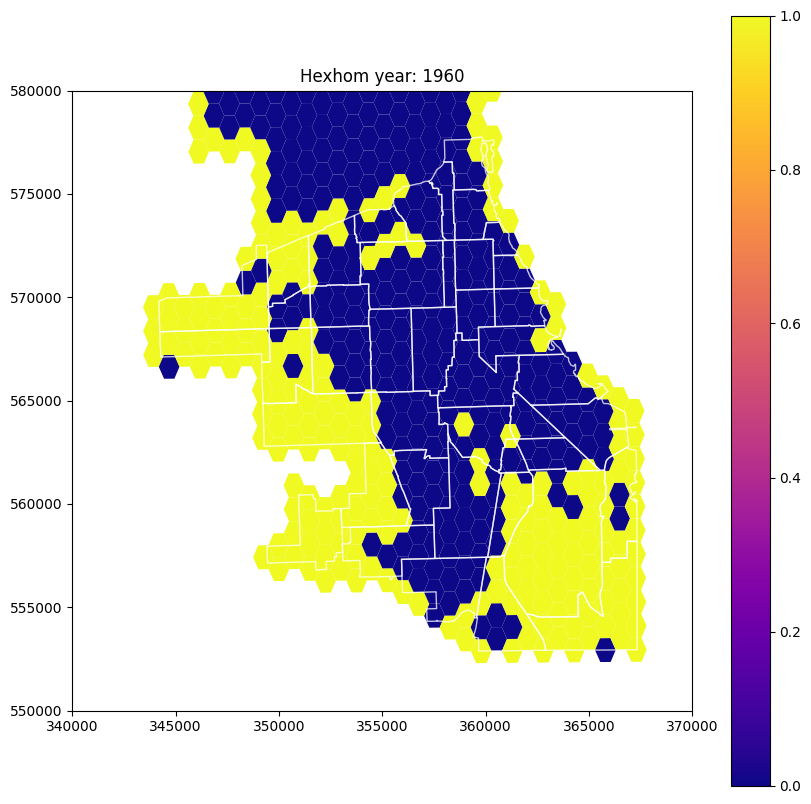

In [37]:
# test plot for cumulative heatmap for south side

x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

hexhom_no_wave_indic[hexhom_no_wave_indic.year==x].plot(column='no_wave_ever', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=1,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)
south_chicago.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
plt.title(f'Hexhom year: {x}')
#plt.close()

In [38]:
#hexhom.groupby('GRID_ID').cum_hom.max().describe()

In [39]:
#create_gif([f'hex_cumu/cumsum_{x}.png' for x in range(1874,2017)], 'hex_cumu/cum_heatmap_1874_2016.gif')

## Combined!

### Southside

True


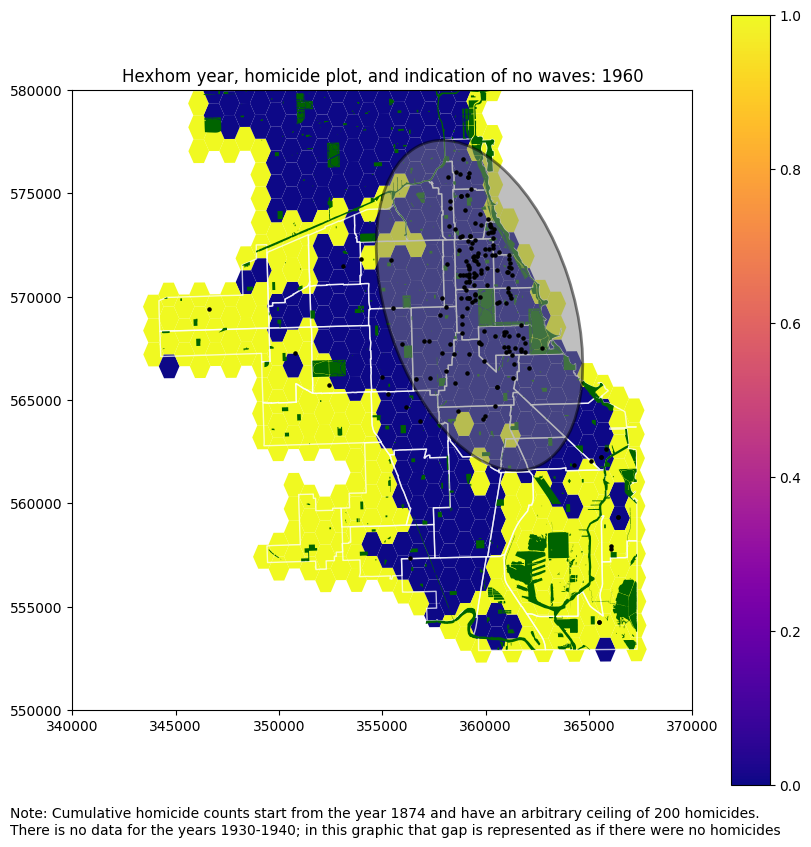

In [40]:
# adding directional ellipse and cumulative heatmap: south side test plot

x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

hexhom_no_wave_indic[hexhom_no_wave_indic.year==x].plot(column='no_wave_ever', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=1,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)

south_chicago.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
parks_water.plot(facecolor='darkgreen', ax=ax)

if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
    print(south_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='gray',
                                 linewidth=2, alpha=0.5,
                                 )

plt.title(f'Hexhom year, homicide plot, and indication of no waves: {x}')
ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()

In [41]:
plt.close()

In [42]:
most_recent = 1874

for x in range(1874, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(550000, 580000)
    plt.xlim(340000, 370000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom_no_wave_indic[hexhom_no_wave_indic.year==i].plot(column='no_wave_ever', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=1,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)
    south_chicago.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    parks_water.plot(facecolor='darkgreen', ax=ax)
    plt.title(f'Hexhom year, homicide plot, and indication of no waves: South Chicago, {x}')

    if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
        #print(south_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='gray',
                                    linewidth=2, alpha=0.5,
                                    )    
    ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
    plt.savefig(f'viz/elip_no_waves/south/elip_no_waves_south_{x}.png')
    #print(f'dist_cum_south/dist_cum_south_{x}.png')
    plt.close()
    most_recent = i

/var/folders/_d/481kb3lx6j307ch206pvy4w40000gn/T/ipykernel_52337/1280652233.py:29: RuntimeWarning: invalid value encountered in sqrt
  width, height = 2 * n_std * np.sqrt(vals)


In [43]:
create_gif([f'viz/elip_no_waves/south/elip_no_waves_south_{x}.png' for x in range(1874, 2017)], 'viz/elip_no_waves/south/elip_no_waves_south_1874_2016.gif')

GIF saved as viz/elip_no_waves/south/elip_no_waves_south_1874_2016.gif in viz/elip_no_waves/south/elip_no_waves_south_1874_2016.gif


### Westside

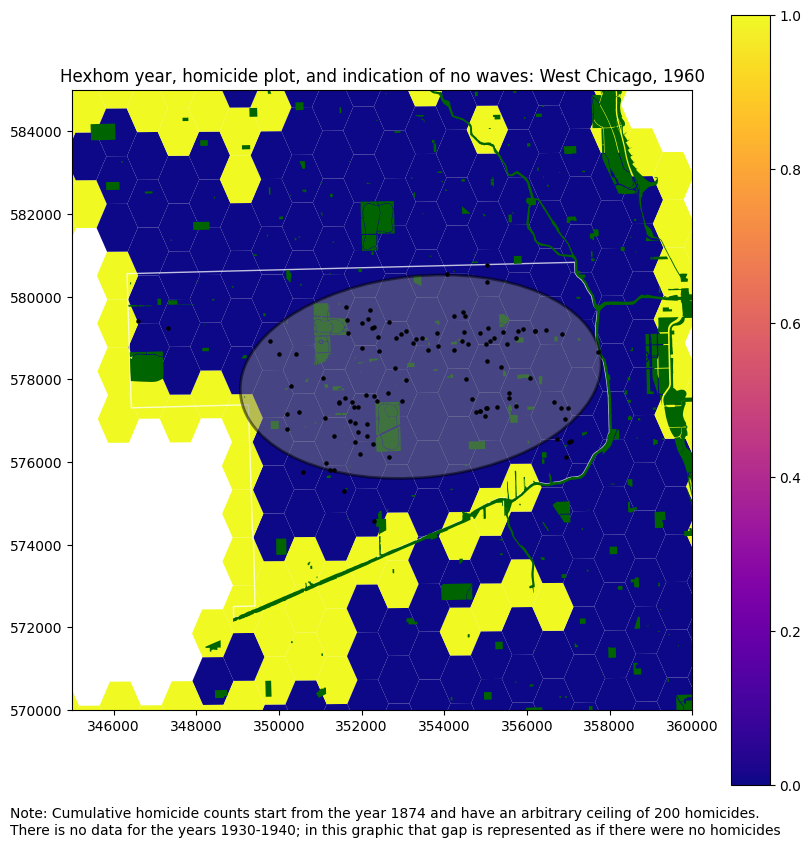

In [44]:
# test plot for cumulative heatmap + directional ellipse: west side:
x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(570000, 585000)
plt.xlim(345000, 360000)

hexhom_no_wave_indic[hexhom_no_wave_indic.year==i].plot(column='no_wave_ever', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=1,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

west_chicago.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
parks_water.plot(facecolor='darkgreen', ax=ax)

if (x in west_hom.year.unique()) and (west_hom.year.value_counts()[x] >= 2):
    #print(west_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(west_hom[west_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='gray',
                                 linewidth=2, alpha=0.5,
                                 )

plt.title(f'Hexhom year, homicide plot, and indication of no waves: West Chicago, {x}')
ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()


In [45]:
most_recent = 1874

for x in range(1874, 2017):

    i = x

    fig, ax = plt.subplots(figsize=(10,10))

    plt.ylim(570000, 585000)
    plt.xlim(345000, 360000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom_no_wave_indic[hexhom_no_wave_indic.year==i].plot(column='no_wave_ever', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=1,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

    west_chicago.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)

    if (x in west_hom.year.unique()) and (west_hom.year.value_counts()[x] >= 2):
        #print(west_hom.year.value_counts()[x] >= 5)
        try:
            plot_directional_ellipse_gdf(west_hom[west_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                        facecolor='gray',
                                        linewidth=2, alpha=0.5,
                                        )
        except AttributeError:
            pass

    plt.title(f'Hexhom year, homicide plot, and indication of no waves: West Chicago, {x}')
    ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
                xy=(-0.1,-0.2),
                xycoords='axes fraction',
                fontsize=10)
    
    most_recent = i
    
    plt.savefig(f'viz/elip_no_waves/west/elip_no_waves_west_{x}.png')
    #print(f'dist_cum_west/dist_cum_west_{x}.png')
    plt.close()

In [46]:
create_gif([f'viz/elip_no_waves/west/elip_no_waves_west_{x}.png' for x in range(1874, 2017)], 'viz/elip_no_waves/west/elip_no_waves_west_1874_2016.gif')

GIF saved as viz/elip_no_waves/west/elip_no_waves_west_1874_2016.gif in viz/elip_no_waves/west/elip_no_waves_west_1874_2016.gif


# Longest Gap Map
**May 14, 2025**

In [130]:
# Clean up text data

longest_gap_un = longest_gap[['GRID_ID', 'geometry', 'last_wave_end', 'longest_gap']].reset_index(drop = True)
longest_gap_un = longest_gap_un.set_index(['GRID_ID'])
longest_gap_un = longest_gap_un.dropna()
longest_gap_un.sort_values(['GRID_ID'])
longest_gap_un = longest_gap_un.drop_duplicates()

# Transform to geodatagram 

from shapely import wkt

longest_gap_un['geometry'] = longest_gap_un['geometry'].apply(wkt.loads)

longest_gap_un

,geometry,last_wave_end,longest_gap
GRID_ID,,,
AL-37,POLYGON ((-87.60066668105532 41.64974613192322...,1996.0,21.0
AS-37,POLYGON ((-87.53758353564956 41.64454312178316...,1976.0,41.0
AH-36,POLYGON ((-87.63671419271566 41.66015215220369...,1977.0,40.0
AK-36,POLYGON ((-87.60967855897036 41.65494914206346...,2017.0,0.0
AL-36,POLYGON ((-87.60066668105532 41.66015215220369...,2012.0,5.0
...,...,...,...
AL-21,POLYGON ((-87.60066668105532 41.81624245640898...,2010.0,7.0
AM-21,POLYGON ((-87.59165480314022 41.81103944626875...,2005.0,12.0
AM-20,POLYGON ((-87.59165480314022 41.82144546654905...,1994.0,23.0


In [ ]:
# Transform longest gap to proper projection

longest_gap_un_shape = gpd.GeoDataFrame(longest_gap_un, geometry='geometry', crs="EPSG:4326")

longest_gap_un_shape_proper = longest_gap_un_shape.to_crs(epsg=26971)

longest_gap_un_shape_proper.head()


,geometry,last_wave_end,longest_gap
GRID_ID,,,
AL-37,"POLYGON ((361032.399 553460.266, 360787.053 55...",1996.0,21.0
AS-37,"POLYGON ((366292.707 552928.977, 366047.763 55...",1976.0,41.0
AH-36,"POLYGON ((358020.221 554591.116, 357774.675 55...",1977.0,40.0
AK-36,"POLYGON ((360276.838 554031.796, 360031.453 55...",2017.0,0.0
AL-36,"POLYGON ((361022.576 554616.009, 360777.271 55...",2012.0,5.0


In [145]:
longest_gap_un_west = gpd.sjoin(longest_gap_un_shape_proper, west_chicago, predicate='within')
com_areas_west = gpd.sjoin(commarea, west_chicago, predicate='intersects')

com_areas_west

,AREA,PERIMETER,COMAREA_,COMAREA_ID,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN,geometry,index_right,name
23,0.0,0.0,0,0,23,HUMBOLDT PARK,23,1.004809e+08,48583.064330,"POLYGON ((353262.344 579883.731, 352977.185 57...",0,westside
24,0.0,0.0,0,0,24,WEST TOWN,24,1.275629e+08,55203.718696,"POLYGON ((356123.223 582414.791, 356124.046 58...",0,westside
25,0.0,0.0,0,0,25,AUSTIN,25,1.992542e+08,75226.474917,"POLYGON ((345121.139 583083.561, 345133.579 58...",0,westside
26,0.0,0.0,0,0,26,WEST GARFIELD PARK,26,3.609285e+07,26238.541980,"POLYGON ((350897.498 577830.825, 350898.178 57...",0,westside
27,0.0,0.0,0,0,27,EAST GARFIELD PARK,27,5.388322e+07,31514.625957,"POLYGON ((353262.344 579883.731, 353419.279 57...",0,westside
28,0.0,0.0,0,0,28,NEAR WEST SIDE,28,1.584925e+08,53003.592941,"POLYGON ((357744.272 579700.785, 357739.044 57...",0,westside
29,0.0,0.0,0,0,29,NORTH LAWNDALE,29,8.948742e+07,44959.459663,"POLYGON ((350897.498 577830.825, 350946.793 57...",0,westside
31,0.0,0.0,0,0,30,SOUTH LAWNDALE,30,1.279983e+08,49904.045210,"POLYGON ((353653.092 573955.859, 353606.734 57...",0,westside
32,0.0,0.0,0,0,31,LOWER WEST SIDE,31,8.155072e+07,43229.372704,"POLYGON ((357971.731 576535.621, 357958.641 57...",0,westside
52,0.0,0.0,0,0,56,GARFIELD RIDGE,56,1.178908e+08,60080.447970,"POLYGON ((349416.197 572137.553, 349418.428 57...",0,westside


## West Side
(Anita did South Side)

<Axes: >

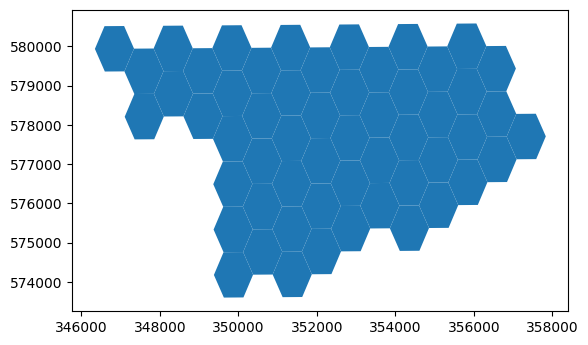

In [136]:
longest_gap_un_west.plot()

<Axes: >

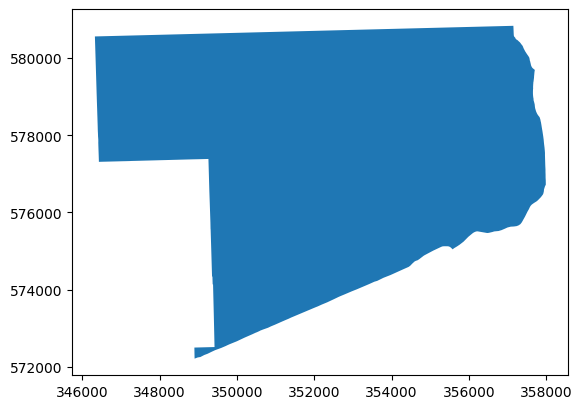

In [133]:
west_chicago.plot()

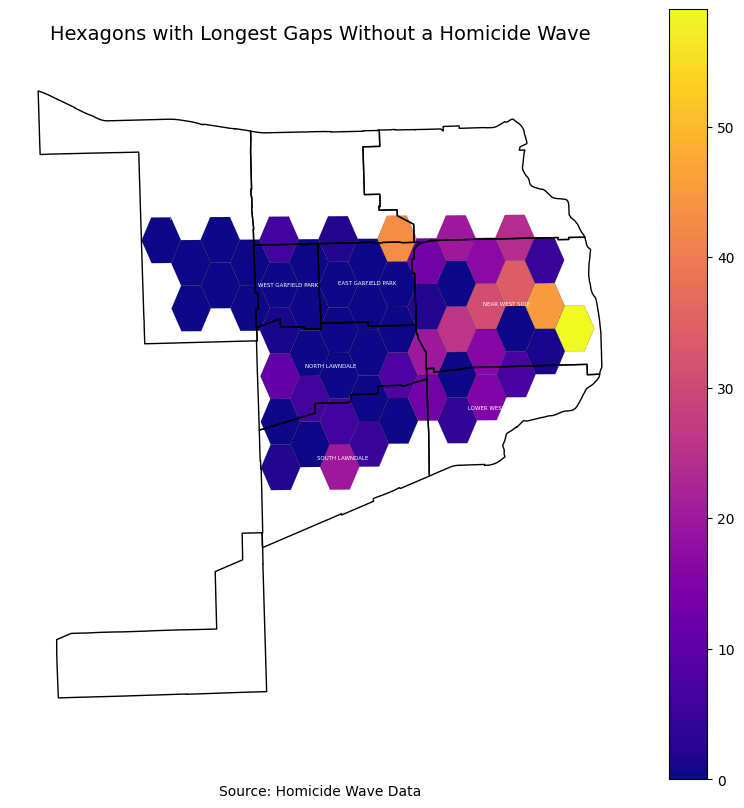

In [146]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all hexagons colored by longest_gap
longest_gap_un_west.plot(column="longest_gap", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax)

# Highlight top hexagons with longest gaps in red
#highlight_hexagons.plot(facecolor="red", edgecolor="black", linewidth=0.2, ax=ax)

# Add labels for highlighted hexagons (GRID_ID)
'''
for x, y, label in zip(highlight_hexagons['geometry'].centroid.x, 
                        highlight_hexagons.geometry.centroid.y, 
                        highlight_hexagons["GRID_ID"]):
    ax.text(x, y, label, fontsize=8, color="white", ha="center", va="center", weight="bold")
    '''

# Plot community boundaries

com_areas_west.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

# Add community labels
for x, y, label in zip(com_areas_west.geometry.centroid.x, 
                        com_areas_west.geometry.centroid.y, 
                        com_areas_west["COMMUNITY"]):
    ax.text(x, y, label, fontsize=4, color="white", ha="center", va="center")


# Title & Labels
ax.set_title("Hexagons with Longest Gaps Without a Homicide Wave", fontsize=14, pad=15)
ax.annotate("Source: Homicide Wave Data", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

# Remove axis labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Optional: Add basemap
# ctx.add_basemap(ax, crs=map_data.crs, source=ctx.providers.CartoDB.Positron)

# Show plot
plt.show()